# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


---
**Penjelasan Dataset Eksperimen:**

**Nama Dataset**: S&P 500 Analyst Rating and Price Target Accuracy

**Sumber Dataset**: [Kaggle](https://www.kaggle.com/)

**Gambaran Singkat**: Dataset ini berisi data historis tentang rating dan target harga yang diberikan oleh para analis keuangan (analyst ratings) terhadap saham-saham yang tergabung dalam indeks S&P 500. Data ini mencakup tanggal event, perusahaan sekuritas (firm), perubahan rekomendasi (from_grade ke to_grade), aksi yang diambil (action), harga target awal dan baru, serta tingkat akurasi (accuracy_30d, accuracy_90d, dll.) untuk memprediksi harga saham pada masa mendatang. Informasi ini sangat berguna untuk menganalisis apakah perubahan rating atau target harga yang diberikan oleh analis benar-benar sejalan dengan pergerakan harga saham di pasar.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [4]:
# Memuat dataset
df = pd.read_csv('/content/drive/MyDrive/BI-OJK/DICODING/sp_500_analyst_rating_and_price_target_accuracy.csv')
df.head()

,ticker,event_date,firm,from_grade,to_grade,action,price_target_action,current_price_target,prior_price_target,implied_direction,forward_return_30d_pct,forward_return_90d_pct,forward_return_180d_pct,forward_return_365d_pct,accuracy_30d,accuracy_90d,accuracy_180d,accuracy_365d
0,A,2026-04-14 21:05:30,Barclays,Overweight,Overweight,main,Lowers,140.0,150.0,1,-5.922417,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1,A,2026-04-13 08:40:20,TD Cowen,Buy,Buy,main,Lowers,147.0,157.0,1,-4.051066,NaN,NaN,NaN,0.0,NaN,NaN,NaN
2,A,2026-04-06 16:14:02,Evercore ISI Group,Outperform,Outperform,main,Lowers,140.0,160.0,1,2.481719,NaN,NaN,NaN,1.0,NaN,NaN,NaN
3,A,2026-03-03 16:38:34,Morgan Stanley,Overweight,Overweight,main,Lowers,160.0,180.0,1,-2.769236,14.491154,NaN,NaN,0.0,1.0,NaN,NaN
4,A,2026-02-26 18:59:51,UBS,Buy,Buy,main,Lowers,165.0,180.0,1,-7.406798,-4.022223,NaN,NaN,0.0,0.0,NaN,NaN


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
# Menampilkan informasi dasar dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71455 entries, 0 to 71454
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ticker                   71455 non-null  object 
 1   event_date               71455 non-null  object 
 2   firm                     71451 non-null  object 
 3   from_grade               71455 non-null  object 
 4   to_grade                 71455 non-null  object 
 5   action                   71455 non-null  object 
 6   price_target_action      61253 non-null  object 
 7   current_price_target     71455 non-null  float64
 8   prior_price_target       71455 non-null  float64
 9   implied_direction        71455 non-null  int64  
 10  forward_return_30d_pct   71455 non-null  float64
 11  forward_return_90d_pct   68707 non-null  float64
 12  forward_return_180d_pct  65080 non-null  float64
 13  forward_return_365d_pct  57704 non-null  float64
 14  accuracy_30d          

In [6]:
# Menampilkan statistik deskriptif
df.describe()

,current_price_target,prior_price_target,implied_direction,forward_return_30d_pct,forward_return_90d_pct,forward_return_180d_pct,forward_return_365d_pct,accuracy_30d,accuracy_90d,accuracy_180d,accuracy_365d
count,71455.000000,71455.000000,71455.000000,71455.000000,68707.000000,65080.000000,57704.000000,71455.000000,68707.000000,65080.000000,57704.000000
mean,226.574661,199.524011,0.556392,1.672628,4.469298,9.587770,19.970619,0.507102,0.516585,0.548494,0.569042
std,446.165209,420.540680,0.830926,10.035790,18.554093,30.808478,59.834752,0.499953,0.499729,0.497647,0.495215
min,0.000000,0.000000,-1.000000,-78.338583,-88.292337,-85.537059,-95.892145,0.000000,0.000000,0.000000,0.000000
25%,50.000000,16.000000,1.000000,-3.380552,-5.026120,-4.563360,-3.680496,0.000000,0.000000,0.000000,0.000000
50%,119.000000,99.000000,1.000000,0.703398,1.957953,5.004740,10.770489,1.000000,1.000000,1.000000,1.000000
75%,250.000000,225.000000,1.000000,6.214599,12.039221,19.291409,33.003775,1.000000,1.000000,1.000000,1.000000
max,10600.000000,10800.000000,1.000000,173.594545,446.856763,1245.621946,3963.334070,1.000000,1.000000,1.000000,1.000000


### EDA Univariate (Kategorikal & Numerikal)

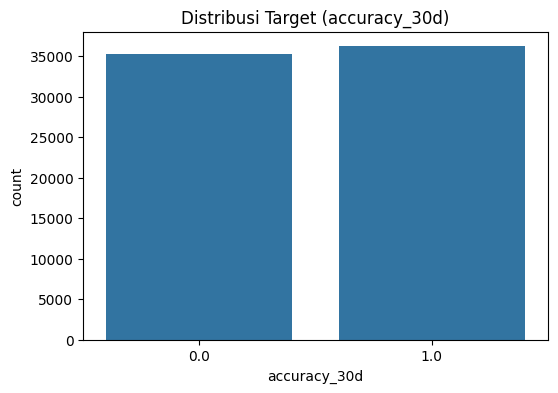

In [7]:
# Distribusi dari kelas target 'accuracy_30d'
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='accuracy_30d')
plt.title('Distribusi Target (accuracy_30d)')
plt.show()

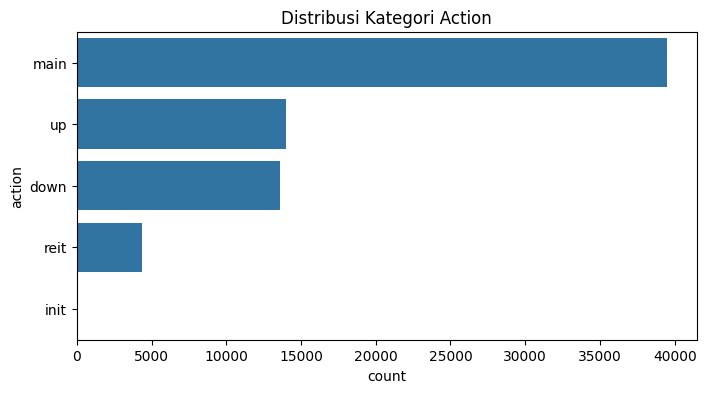

In [8]:
# Distribusi fitur kategorikal 'action'
plt.figure(figsize=(8,4))
sns.countplot(data=df, y='action', order=df['action'].value_counts().index)
plt.title('Distribusi Kategori Action')
plt.show()

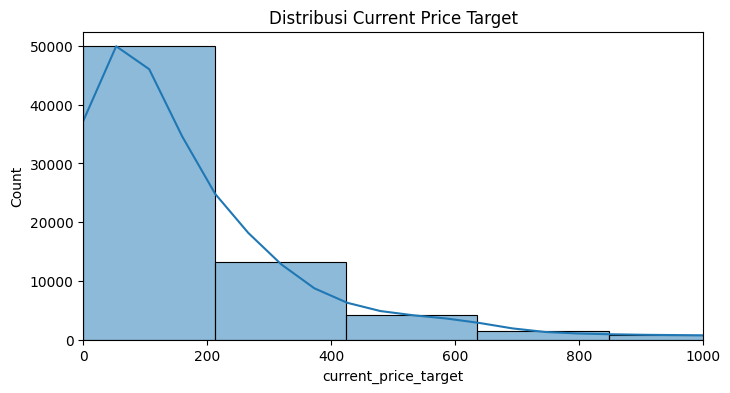

In [9]:
# Distribusi numerikal 'current_price_target' menggunakan Histogram
plt.figure(figsize=(8,4))
sns.histplot(df['current_price_target'], bins=50, kde=True)
plt.title('Distribusi Current Price Target')
plt.xlim(0, 1000) # Membatasi x-axis agar tidak terkena skew ekstrem
plt.show()

### EDA Multivariate (Hubungan antar variabel)

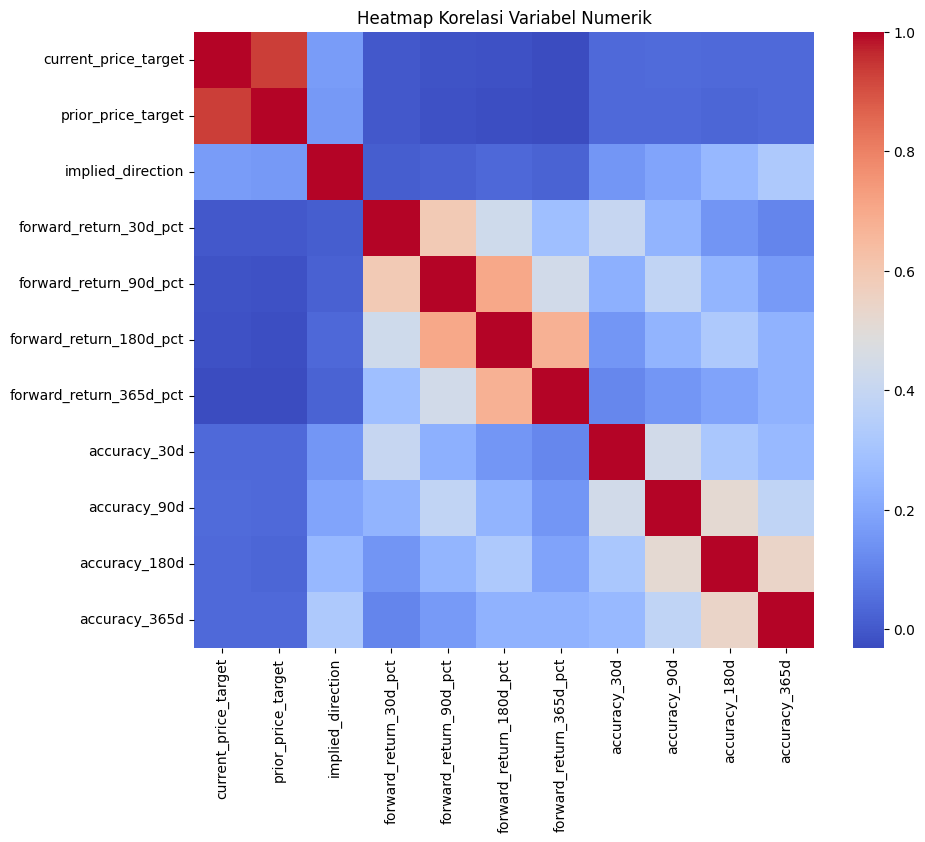

In [10]:
# Korelasi antar variabel numerik
plt.figure(figsize=(10,8))
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Heatmap Korelasi Variabel Numerik')
plt.show()

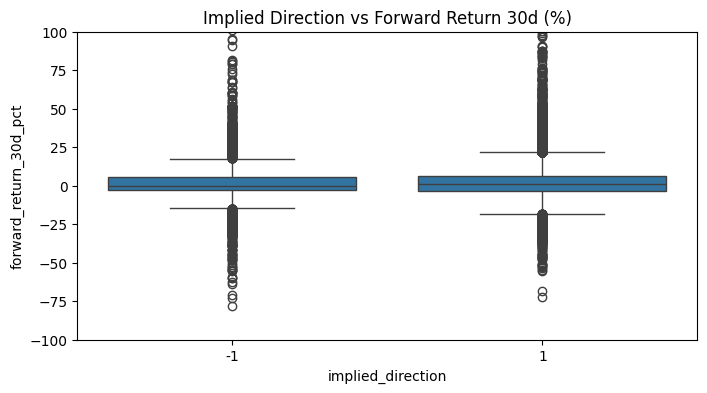

In [11]:
# Bivariate: Hubungan implied_direction dengan forward_return_30d_pct
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='implied_direction', y='forward_return_30d_pct')
plt.title('Implied Direction vs Forward Return 30d (%)')
plt.ylim(-100, 100) # membatasi visualisasi
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [12]:
# 1. Menghapus atau Menangani Data Kosong
# Memilih fitur yang relevan untuk diolah
features = ['from_grade', 'to_grade', 'action', 'implied_direction']
target = 'accuracy_30d'

# Drop data kosong pada subset target dan features
df_clean = df.dropna(subset=[target] + features).copy()
print(f'Jumlah baris setelah drop missing values pada kolom terpilih: {df_clean.shape[0]}')

Jumlah baris setelah drop missing values pada kolom terpilih: 71455


In [13]:
# 2. Encoding Data Kategorikal
le = LabelEncoder()
for col in ['from_grade', 'to_grade', 'action']:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

df_clean.head()

,ticker,event_date,firm,from_grade,to_grade,action,price_target_action,current_price_target,prior_price_target,implied_direction,forward_return_30d_pct,forward_return_90d_pct,forward_return_180d_pct,forward_return_365d_pct,accuracy_30d,accuracy_90d,accuracy_180d,accuracy_365d
0,A,2026-04-14 21:05:30,Barclays,26,23,2,Lowers,140.0,150.0,1,-5.922417,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1,A,2026-04-13 08:40:20,TD Cowen,5,4,2,Lowers,147.0,157.0,1,-4.051066,NaN,NaN,NaN,0.0,NaN,NaN,NaN
2,A,2026-04-06 16:14:02,Evercore ISI Group,24,21,2,Lowers,140.0,160.0,1,2.481719,NaN,NaN,NaN,1.0,NaN,NaN,NaN
3,A,2026-03-03 16:38:34,Morgan Stanley,26,23,2,Lowers,160.0,180.0,1,-2.769236,14.491154,NaN,NaN,0.0,1.0,NaN,NaN
4,A,2026-02-26 18:59:51,UBS,5,4,2,Lowers,165.0,180.0,1,-7.406798,-4.022223,NaN,NaN,0.0,0.0,NaN,NaN
